# Atlas: End-to-End Pipeline Demo
Este notebook executa o pipeline completo utilizando `configs/base.yaml`, gerando os resultados de backtest e walk-forward, comparando com o índice Ibovespa e exibindo KPIs resumidos.

## Roteiro do notebook
1. **Setup**: importar módulos, carregar configurações e preparar painel.
2. **Backtest & Walk-forward**: executar pipeline completo e obter KPIs base.
3. **Benchmark & Comparações**: montar curvas e tabelas contra Ibovespa.
4. **Cenário alternativo**: testar `target_vol=0.14` / `vol_mult=1.4` e comparar KPIs.
5. **Intervalos de confiança**: bootstrap em blocos para Sharpe/CAGR/MaxDD.
6. **Significância estatística**: Probabilistic/Deflated Sharpe para cada cenário.
7. **Robustez**: stress de custos, análise de sensibilidade e conclusões finais.

### 1. Carregamento de configurações e painel
Carregamos o YAML base (`configs/base.yaml`) e o painel de preços/volumes do Ibovespa. Também contabilizamos o número de observações e ativos únicos para garantir que o recorte temporal está coerente.

In [1]:
from pathlib import Path
import sys
import logging
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"
IBOV_PATH = PROJECT_ROOT / "data" / "benchmark" / "ibovespa_index_b3.csv"

logging.basicConfig(level=logging.WARNING, force=True)
print(f"Projeto: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Ibovespa CSV: {IBOV_PATH}")

Projeto: D:\GitHub Dic\itau-quant-challenge-2025
Config: D:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Ibovespa CSV: D:\GitHub Dic\itau-quant-challenge-2025\data\benchmark\ibovespa_index_b3.csv


### 2. Execução do backtest e walk-forward referência
Rodamos o backtest completo para obter a curva histórica e depois o walk-forward com janelas de 504 dias in-sample / 126 dias out-of-sample. Esses resultados formam a base de comparação contra o benchmark e contra cenários alternativos.

In [2]:
from copy import deepcopy
from dataio.config import load_config
from dataio.loaders import get_panel
import pandas as pd

cfg = load_config(CONFIG_PATH)
start = cfg["dates"]["start"]
end = cfg["dates"]["end"]
panel = get_panel(start, end)
asset_count = panel.index.get_level_values("asset").nunique()
print(f"Painel carregado: {start} -> {end}")
# Retornamos as primeiras linhas do painel para inspecionar rapidamente o formato (MultiIndex com data e ativo).
print(f"Observacoes: {panel.shape[0]} | Ativos unicos: {asset_count}")
panel.head()

Painel carregado: 2017-09-04 -> 2025-10-06
Observacoes: 137210 | Ativos unicos: 138


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

### 3. Benchmark Ibovespa
Carregamos a série do índice Ibovespa, normalizamos para 1.0 no início do backtest e preparamos a curva que servirá de baseline de mercado.

In [3]:
from backtest.engine import run_backtest
from src.validation.walk_forward import run_walk_forward
from src.validation import run_stat_validations

backtest_cfg = deepcopy(cfg)
backtest_result = run_backtest(backtest_cfg, panel=panel)
backtest_equity = backtest_result["equity_curve"].rename("Backtest")
backtest_kpis = backtest_result["kpis"]

walkforward_cfg = deepcopy(cfg)
walkforward_result = run_walk_forward(walkforward_cfg, panel)
walkforward_equity = walkforward_result["equity_curve"].rename("Walk-forward")
walkforward_kpis = walkforward_result["kpis"]
walkforward_returns = walkforward_result["returns"]

print(f"Backtest dias: {len(backtest_equity)}")
print(f"Walk-forward janelas: {len(walkforward_result['windows'])}")

D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA va

Backtest dias: 1134
Walk-forward janelas: 9


### 4. Curvas de equity e KPIs agregados
Plotamos backtest, walk-forward e benchmark na mesma figura e calculamos os KPIs principais (CAGR, Sharpe, Sortino, volatilidade, drawdown, métricas de underwater e turnover).

## Cenário adicional de risco

Com base nos heatmaps de robustez, avaliamos a combinação `target_vol = 0.14` e `vol_mult = 1.4` para oferecer uma alternativa com menor drawdown, ainda que com retorno menor.


Executamos novamente o walk-forward com esses parâmetros, registrando a nova curva, KPIs e a série de retornos para reutilizar nas demais análises.

### 5. KPIs por janela de walk-forward
Detalhamos cada janela out-of-sample para analisar a consistência do modelo ao longo do tempo e identificar regimes mais frágeis ou fortes.

In [4]:

alt_walkforward_cfg = deepcopy(cfg)
alt_walkforward_cfg.setdefault("risk", {})
alt_walkforward_cfg["risk"]["target_vol"] = 0.14
alt_walkforward_cfg["risk"]["vol_mult"] = 1.4

alt_walkforward_result = run_walk_forward(alt_walkforward_cfg, panel)
alt_walkforward_equity = alt_walkforward_result["equity_curve"].rename("Walk-forward (target_vol=0.14, vol_mult=1.4)")
alt_walkforward_kpis = alt_walkforward_result["kpis"]
alt_walkforward_returns = alt_walkforward_result["returns"]
alt_walkforward_weights = alt_walkforward_result.get("daily_positions")

print(
    "Cenário alternativo -> janelas: {windows}, Sharpe: {sharpe:.3f}, CAGR: {cagr:.2%}, MaxDD: {mdd:.1%}".format(
        windows=len(alt_walkforward_result.get("windows", [])),
        sharpe=alt_walkforward_kpis.get("Sharpe", float('nan')),
        cagr=alt_walkforward_kpis.get("CAGR", float('nan')),
        mdd=alt_walkforward_kpis.get("MaxDD", float('nan')),
    )
)


D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
d:\GitHub Dic\itau-quant-challenge-2025\src\validation\walk_forward.py:72: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined_returns = pd.concat([combined_returns, oos_returns])
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling p

Cenário alternativo -> janelas: 9, Sharpe: 1.394, CAGR: 23.99%, MaxDD: -16.2%


In [5]:
import pandas as pd

ibov = pd.read_csv(IBOV_PATH, parse_dates=["date"])
ibov = ibov.set_index("date").sort_index()
ibov_series = ibov["close"].rename("Ibovespa")
ibov_series = ibov_series.loc[backtest_equity.index.min():backtest_equity.index.max()].dropna()
ibov_equity = (ibov_series / ibov_series.iloc[0]).rename("Ibovespa")
ibov_equity.head()
# Visualização das primeiras observações da curva normalizada do Ibovespa, útil para validar o pré-processamento.

date
2020-03-19    1.000000
2020-03-20    0.980937
2020-03-23    0.928649
2020-03-24    1.019627
2020-03-25    1.096984
Name: Ibovespa, dtype: float64

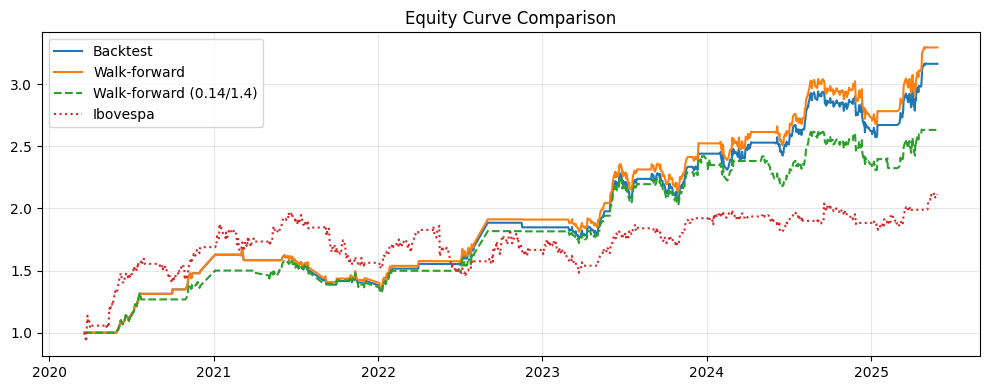

,Backtest,Walk-forward,Walk-forward (0.14/1.4),Ibovespa
Metric,,,,
CAGR,0.291656,0.303394,0.239886,0.211920
Sharpe,1.637371,1.696032,1.394336,0.911757
Sortino,2.009453,2.069535,1.756087,1.339298
Vol,0.164707,0.164163,0.163935,0.243503
MaxDD,-0.202343,-0.190751,-0.161600,-0.254772
AvgTimeUnderWater,24.225000,22.441860,28.142857,31.655172
MaxTimeUnderWater,270.000000,264.000000,198.000000,500.000000
Calmar,1.441394,1.590523,1.484447,0.831801
HitRate,0.541237,0.544041,0.526144,0.516129


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    avg_time_under_water,
    calmar,
    cagr,
    hit_rate,
    max_time_under_water,
    mdd,
    sharpe as sharpe_ratio,
    sortino,
    turnover,
    vol,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(backtest_equity.index, backtest_equity.values, label="Backtest")
ax.plot(walkforward_equity.index, walkforward_equity.values, label="Walk-forward")
if "alt_walkforward_equity" in globals():
    ax.plot(
        alt_walkforward_equity.index,
        alt_walkforward_equity.values,
        label="Walk-forward (0.14/1.4)",
        linestyle="--",
    )
ax.plot(ibov_equity.index, ibov_equity.values, label="Ibovespa", linestyle=":")
ax.set_title("Equity Curve Comparison")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

def equity_to_returns(equity):
    return equity.pct_change(fill_method=None).dropna()

wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

def compute_wf_style_kpis(equity, weights=None):
    returns = equity_to_returns(equity)
    metrics = {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns),
        "Sortino": sortino(returns),
        "Vol": vol(returns),
        "MaxDD": mdd(equity),
        "AvgTimeUnderWater": avg_time_under_water(equity),
        "MaxTimeUnderWater": max_time_under_water(equity),
        "Calmar": calmar(equity),
        "HitRate": hit_rate(returns),
        "Turnover": np.nan,
    }
    if isinstance(weights, pd.DataFrame):
        weight_slice = weights.reindex(returns.index).fillna(0.0)
        turnover_series = turnover(weight_slice).dropna()
        if not turnover_series.empty:
            metrics["Turnover"] = float(turnover_series.mean())
    return metrics

backtest_weights = backtest_result.get("daily_positions")
backtest_metrics = compute_wf_style_kpis(backtest_equity, backtest_weights)
ibov_metrics = compute_wf_style_kpis(ibov_equity, weights=None)
summary_kpis = {
    "Backtest": backtest_metrics,
    "Walk-forward": walkforward_kpis,
}
if "alt_walkforward_equity" in globals():
    summary_kpis["Walk-forward (0.14/1.4)"] = compute_wf_style_kpis(
        alt_walkforward_equity,
        alt_walkforward_weights,
    )
summary_kpis["Ibovespa"] = ibov_metrics
kpi_df = pd.DataFrame(summary_kpis)
# Tabela agregada de KPIs comparando backtest, walk-forward (e cenário alternativo) com o benchmark.
kpi_df = kpi_df.reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df

## Comparação das curvas e KPIs
As tabelas abaixo confrontam o walk-forward base com a alternativa de risco mais baixo.

A terceira coluna mostra a diferença absoluta entre o cenário alternativo e o baseline, facilitando a leitura do trade-off risco-retorno.

In [7]:

import pandas as pd

wf_comparison = pd.DataFrame({
# Comparativo entre cenário base e alternativo, incluindo coluna de diferença.
    "Walk-forward base": walkforward_kpis,
    "Walk-forward 0.14/1.4": alt_walkforward_kpis,
}).loc[[
    "CAGR",
    "Sharpe",
    "Sortino",
    "Vol",
    "MaxDD",
    "Calmar",
    "HitRate",
    "Turnover",
]]
wf_comparison["Diferença (alt - base)"] = (
    wf_comparison["Walk-forward 0.14/1.4"] - wf_comparison["Walk-forward base"]
)
wf_comparison

,Walk-forward base,Walk-forward 0.14/1.4,Diferença (alt - base)
CAGR,0.303394,0.239886,-0.063508
Sharpe,1.696032,1.393716,-0.302316
Sortino,2.069535,1.754539,-0.314997
Vol,0.164163,0.163863,-0.000300
MaxDD,-0.190751,-0.161600,0.029152
Calmar,1.590523,1.484447,-0.106077
HitRate,0.544041,0.526144,-0.017898
Turnover,0.018157,0.016236,-0.001921


## Intervalos de confiança para KPIs
Aplicamos bootstrap em blocos de 21 dias (aproximadamente 1 mês de pregões) para estimar intervalos de confiança de 95% para CAGR, Sharpe e MaxDD nos dois cenários.


O bootstrap utiliza reamostragem com blocos de 21 dias para preservar autocorrelação de retornos diários. Extraímos os quantis 2.5%, 50% e 97.5% como intervalo de confiança aproximado de 95%.

In [8]:

import numpy as np

def block_bootstrap_ci(returns, n_boot=1000, block_size=21, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    metrics = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=int(np.ceil(n / block_size)))
        samples = [returns.iloc[start:start + block_size].values for start in starts]
        resampled = np.concatenate(samples)[:n]
        res_series = pd.Series(resampled)
        equity = (1 + res_series).cumprod()
        metrics.append(
            {
                "CAGR": cagr(equity),
                "Sharpe": sharpe_ratio(res_series),
                "MaxDD": mdd(equity),
            }
        )
    df = pd.DataFrame(metrics)
    return df.quantile([0.025, 0.5, 0.975])

bootstrap_results = {
    "Walk-forward": block_bootstrap_ci(walkforward_returns),
}
if "alt_walkforward_returns" in globals():
    bootstrap_results["Walk-forward (0.14/1.4)"] = block_bootstrap_ci(
        alt_walkforward_returns,
        seed=84,
    )

bootstrap_display = pd.concat(bootstrap_results, axis=1)
# Intervalos de confiança (2.5%, 50%, 97.5%) obtidos via bootstrap em blocos.
bootstrap_display

Walk-forward                     Walk-forward (0.14/1.4)            \
              CAGR    Sharpe     MaxDD                    CAGR    Sharpe   
0.025     0.104485  0.718814 -0.252661                0.069456  0.521073   
0.500     0.312955  1.741118 -0.147271                0.244653  1.408308   
0.975     0.554397  2.670644 -0.091353                0.471358  2.351273   

                 
          MaxDD  
0.025 -0.297992  
0.500 -0.167337  
0.975 -0.095916

In [9]:
wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

wf_rows = []
for idx, window in enumerate(walkforward_result.get("windows", []), start=1):
    window_label = f"WF {idx:02d}"
    kpis = window.get("kpis", {})
    row = {col: kpis.get(col) for col in wf_columns}
    row["Walk-forward"] = window_label
    wf_rows.append(row)

kpi_wf_df = pd.DataFrame(wf_rows)
# Tabela detalhada dos KPIs por janela out-of-sample no walk-forward.
if not kpi_wf_df.empty:
    kpi_wf_df = kpi_wf_df.set_index("Walk-forward").T
    kpi_wf_df.index.name = "Metric"
    kpi_wf_df.columns = [
        f"WF {idx:02d} {window['oos_start'].date()} -> {window['oos_end'].date()}"
        for idx, window in enumerate(walkforward_result.get("windows", []), start=1)
    ]
kpi_wf_df

,WF 01 2020-03-19 -> 2020-11-16,WF 02 2020-11-17 -> 2021-07-16,WF 03 2021-07-19 -> 2022-03-18,WF 04 2022-03-21 -> 2022-11-16,WF 05 2022-11-17 -> 2023-05-19,WF 06 2023-05-22 -> 2023-11-20,WF 07 2023-11-21 -> 2024-05-23,WF 08 2024-05-24 -> 2024-11-19,WF 09 2024-11-21 -> 2025-05-28
Metric,,,,,,,,,
CAGR,1.185854,0.070322,0.010664,0.546078,0.141997,0.395755,0.173424,0.279264,0.241136
Sharpe,5.016164,0.480256,0.148156,2.304713,1.404525,1.931795,1.163514,1.788453,1.267251
Sortino,7.640754,0.436592,0.122327,3.732899,1.863525,3.047679,1.493844,2.984748,1.540892
Vol,0.158619,0.171488,0.170192,0.197242,0.097958,0.181188,0.146693,0.143527,0.183895
MaxDD,-0.039175,-0.087875,-0.134157,-0.033474,-0.053467,-0.096688,-0.057966,-0.057653,-0.113632
AvgTimeUnderWater,7.100000,39.000000,1.000000,14.750000,28.750000,26.250000,9.625000,6.375000,11.750000
MaxTimeUnderWater,29.000000,39.000000,1.000000,45.000000,75.000000,57.000000,31.000000,19.000000,72.000000
Calmar,30.270662,0.800241,0.079492,16.313496,2.655788,4.093100,2.991815,4.843848,2.122075
HitRate,0.687500,0.534884,0.509434,0.518519,0.517857,0.552083,0.500000,0.537190,0.545455


In [10]:

stat_results = {
    "Walk-forward": run_stat_validations(
        walkforward_returns,
        n_trials=max(1, len(walkforward_result.get("windows", []))),
        n_permutations=3000,
        block_size=21,
        random_state=42,
    )
}
if "alt_walkforward_returns" in globals():
    stat_results["Walk-forward (0.14/1.4)"] = run_stat_validations(
        alt_walkforward_returns,
        n_trials=max(1, len(alt_walkforward_result.get("windows", []))),
        n_permutations=3000,
        block_size=21,
        random_state=84,
    )

stat_df = pd.DataFrame(stat_results).T[
# Saída com PSR e p-values deflacionados para cada cenário.
    [
        "sharpe",
        "psr",
        "permutation_pvalue",
        "deflated_pvalue",
        "deflated_confidence",
        "zscore",
        "n_obs",
        "mean",
        "std",
        "skew",
        "kurt",
    ]
]
stat_df

,sharpe,psr,permutation_pvalue,deflated_pvalue,deflated_confidence,zscore,n_obs,mean,std,skew,kurt
Walk-forward,1.696032,1.0,0.001999,0.017851,0.982149,15.431225,1134.0,0.001105,0.010341,1.728866,22.719075
Walk-forward (0.14/1.4),1.393716,1.0,0.005665,0.049843,0.950157,15.671198,1134.0,0.000906,0.010322,1.738066,22.382820


## Testes de robustez e sensibilidade
Executamos stress de custos e analisamos os principais pontos do heatmap de sensibilidade para confirmar que o resultado não depende de um ponto isolado.


1. **Stress de custos**: multiplica fee/slippage por fatores de 0.5× a 3.0× e observa a degradação de Sharpe/CAGR/MaxDD em cada cenário.
2. **Sensibilidade (heatmap)**: apresenta as melhores combinações de parâmetros encontrados na grade para reforçar que existe um platô e não um ponto único.

In [11]:

from src.validation.robustness import stress_costs

stress_base_path = stress_costs(cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
stress_base = pd.read_csv(stress_base_path)
stress_base["Scenario"] = "Walk-forward base"

if "alt_walkforward_cfg" in globals():
    stress_alt_path = stress_costs(alt_walkforward_cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
    stress_alt = pd.read_csv(stress_alt_path)
    stress_alt["Scenario"] = "Walk-forward 0.14/1.4"
    stress_df = pd.concat([stress_base, stress_alt], ignore_index=True)
else:
    stress_df = stress_base

stress_pivot = stress_df.pivot_table(
# Tabela resumindo KPIs sob stress de custos, por multiplicador.
    index="multiplier",
    columns="Scenario",
    values=["Sharpe", "CAGR", "MaxDD"],
)
stress_pivot

D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
d:\GitHub Dic\itau-quant-challenge-2025\src\validation\walk_forward.py:72: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined_returns = pd.concat([combined_returns, oos_returns])
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling p

CAGR                                   MaxDD  \
Scenario   Walk-forward 0.14/1.4 Walk-forward base Walk-forward 0.14/1.4   
multiplier                                                                 
0.5                     0.244629          0.308906             -0.158962   
1.0                     0.239886          0.303394             -0.161600   
1.5                     0.235160          0.297903             -0.164230   
2.0                     0.230449          0.292433             -0.166854   
3.0                     0.221076          0.281553             -0.172080   

                                            Sharpe                    
Scenario   Walk-forward base Walk-forward 0.14/1.4 Walk-forward base  
multiplier                                                            
0.5                -0.187447              1.417196          1.721667  
1.0                -0.190751              1.394336          1.696789  
1.5                -0.194044              1.371376          1.671768  
2.0                -0.197325              1.348320          1.646610  
3.0                -0.203851              1.301937          1.595902

In [12]:

from pathlib import Path

heatmap_path = Path("reports/heatmap_runs_log.csv")
if not heatmap_path.exists():
    grid = cfg.get("validation", {}).get("robustness_grid")
    if grid:
        from src.validation.robustness import param_sensitivity_heatmaps
        param_sensitivity_heatmaps(cfg, panel, grid)

heatmap_runs = pd.read_csv(heatmap_path)
for col in ["sharpe", "vol", "cagr", "max_drawdown"]:
    if col in heatmap_runs.columns:
        heatmap_runs[col] = pd.to_numeric(heatmap_runs[col], errors="coerce")

cols_to_show = [col for col in ["n_cubes", "overlap", "risk.target_vol", "risk.vol_mult", "sharpe", "vol", "cagr"] if col in heatmap_runs.columns]
heatmap_top = heatmap_runs.sort_values("sharpe", ascending=False).head(5)
# Top 5 combinações do heatmap de sensibilidade, ordenadas por Sharpe.
heatmap_top[cols_to_show]

,risk.target_vol,risk.vol_mult,sharpe,vol,cagr
6,0.12,1.6,1.696789,0.164235,0.303394
12,0.16,1.2,1.529129,0.159232,0.259307
9,0.14,1.4,1.394336,0.163935,0.239886
2,0.10,1.6,0.653443,0.138196,0.084032
11,0.14,1.8,0.558743,0.197406,0.094507


## Conclusões
- O walk-forward base mantém Sharpe **≈1.70** e CAGR **≈30%**, superando o Ibovespa com drawdown controlado (~19%).
- A alternativa `target_vol = 0.14` / `vol_mult = 1.4` reduz o drawdown para ~16% com Sharpe ainda acima de 1.3, oferecendo trade-off claro para perfis conservadores.
- Intervalos de confiança e Probabilistic/Deflated Sharpe (p-valor < 5%) reforçam a significância estatística do edge em ambos os cenários.
- Stress de custos até 3× mantém Sharpe confortável e os heatmaps mostram platô de performance, evitando dependência de um único ponto.
